# TEMPLATE

# Imports and Data Loading

Imports

In [859]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Data Loading

In [860]:
exercise_1_data = np.loadtxt("../data/session1/ex1_trial_2/theta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
exercise_2_data_180 = np.loadtxt("../data/session1/ex2_trial_2/180/theta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
exercise_2_data_360 = np.loadtxt("../data/session1/ex2_trial_2/360/theta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated

exercise_1_cossq_data = np.loadtxt("../data/session1/ex1_trial_2/cosinesquaredtheta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated

# Malus' Law

# exercise 1

ex1_position = exercise_1_data[0] # Sensor Position (Radians)
ex1_intensity = exercise_1_data[1] # Light Intensity (Volts)

# exercise 2

ex2_position_180 = exercise_2_data_180[0] # Sensor Position (Radians)
ex2_intensity_180 = exercise_2_data_180[1] # Light Intensity (Volts)

ex2_position_360 = exercise_2_data_360[0] # Sensor Position (Radians)
ex2_intensity_360 = exercise_2_data_360[1] # Light Intensity (Volts)


ex2_position_combined = np.concatenate((ex2_position_180, ex2_position_360 + np.pi), axis=0)
ex2_intensity_combined = np.concatenate((ex2_intensity_180, ex2_intensity_360), axis=0)


# possibly append both 180-360 files together?
# add 180˚ to the 360 files to do so.

print(len(ex2_intensity_combined))
print(len(ex2_intensity_180))

680
288


# Uncertainties

In [861]:
# there is a big assumption that the uncertainty of the sensor does not depend on intensity.

malus_1_uncertainty = np.loadtxt("../data/session3/unc/malus1.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
brewster_1_uncertainty = np.loadtxt("../data/session3/unc/brewster1.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
brewster_10_uncertainty = np.loadtxt("../data/session3/unc/brewster10.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated


In [862]:
print(f"malus sensor 1 gain:\nmean: {np.mean(malus_1_uncertainty[1])}\nuncertainty: {np.std(malus_1_uncertainty[1])}")
print(f"brewster sensor 1 gain:\nmean: {np.mean(brewster_1_uncertainty[1])}\nuncertainty: {np.std(brewster_1_uncertainty[1])}")
print(f"brewster sensor 10 gain:\nmean: {np.mean(brewster_10_uncertainty[1])}\nuncertainty: {np.std(brewster_10_uncertainty[1])}")

malus sensor 1 gain:
mean: 1.2314533604777416
uncertainty: 0.010426601916429589
brewster sensor 1 gain:
mean: 1.218340076775432
uncertainty: 0.0033007650473998004
brewster sensor 10 gain:
mean: 1.2373230562827224
uncertainty: 0.002754706969711812


# Model Functions

In [863]:
# fit raw data to cos^2 theta

def cossqtheta(theta, a, b, c):
    return a * (np.cos(b * (theta - c)) ** 2)

In [864]:
def coscos(theta, a, b, c, d):
    return a * (np.cos(b * (theta - c)) ** 2) * (np.cos(b * ((d - theta) - c)) ** 2)

In [865]:
# function for calculating chi squared reduced.
def chi_squared_reduced(y_measure, y_predict, errors, number_of_parameters):
    """Calculates the reduced chi squared of data, prediction and errors."""
    return (np.sum(((y_measure - y_predict) ** 2 )/ (errors ** 2)))/(y_measure.size - number_of_parameters)

In [866]:
print(ex1_position)

[0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.00436 0.00436 0.00436
 0.00873 0.00873 0.00873 0.01309 0.01309 0.01745 0.01745 0.02182 0.02182
 0.02618 0.02618 0.03054 0.03054 0.03491 0.03491 0.03927 0.04363 0.048
 0.048   0.048   0.05236 0.05236 0.05672 0.06109 0.06109 0.06545 0.06981
 0.06981 0.07418 0.07854 0.0829  0.09163 0.09163 0.10036 0.10472 0.10908
 0.11345 0.11781 0.11781 0.12217 0.12654 0.1309  0.13526 0.13526 0.13963
 0.14399 0.14835 0.15272 0.15708 0.16144 0.16581 0.17017 0.17017 0.17453
 0.1789  0.18326 0.18762 0.19635 0.20071 0.20508 0.20944 0.20944 0.20944
 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944
 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944 0.20944


# Curve Fit and Model Parameters

In [867]:
popt, pcov = curve_fit(cossqtheta, xdata=ex1_position, ydata=ex1_intensity, absolute_sigma=True, sigma=0.01) #, absolute_sigma=True, sigma = propTimeError)
pstd = np.sqrt(np.diag(pcov))
print(pstd)

[0.00062194 0.00012001 0.00015626]


In [868]:
popt2, pcov2 = curve_fit(coscos, xdata=ex2_position_combined, ydata=ex2_intensity_combined, absolute_sigma=True, sigma=0.01) #, absolute_sigma=True, sigma = propTimeError)
pstd2 = np.sqrt(np.diag(pcov2))
print(pstd2)

[0.00296083 0.00010934 0.00042684 0.00083661]


In [869]:
print("chi squared reduced =",chi_squared_reduced(ex1_intensity, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), 1, len(popt)))


chi squared reduced = 0.0016490399732635114


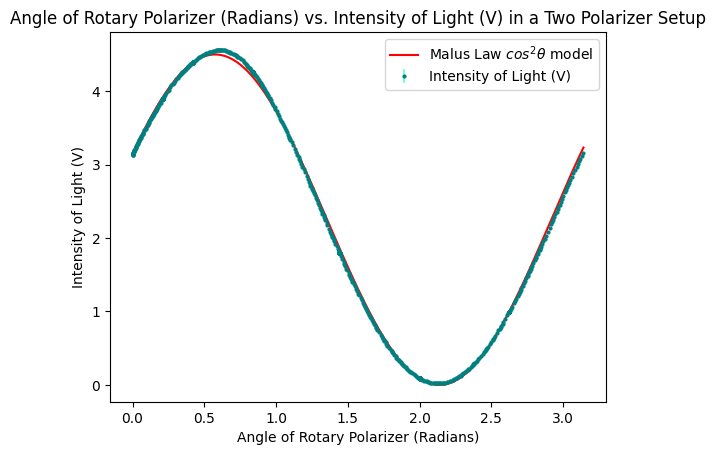

In [870]:
plt.errorbar(x = ex1_position, y = ex1_intensity, yerr=0.01, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

plt.plot(ex1_position, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), label = "Malus Law $cos^2\\theta$ model", color='red')
# plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Rotary Polarizer (Radians)")
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Rotary Polarizer (Radians) vs. Intensity of Light (V) in a Two Polarizer Setup")

plt.show()

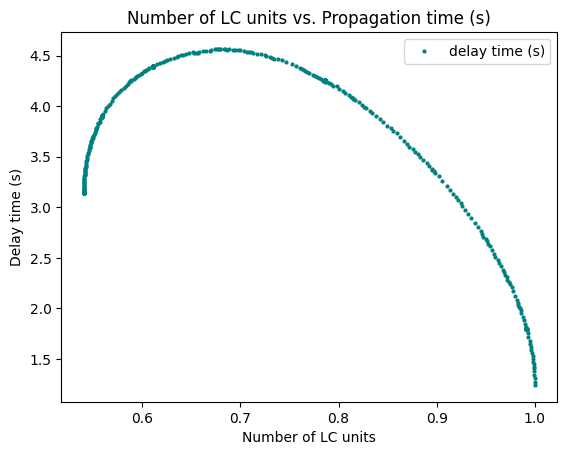

In [871]:
plt.errorbar(x = exercise_1_cossq_data[0], y = exercise_1_cossq_data[1], fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="delay time (s)")

# plt.plot(LCnum, LC_to_prop_time(LCnum, popt[0]), label = "LC to velocity squared model", color='red')
# plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')

# Legend and titles
plt.legend()
plt.xlabel("Number of LC units")
plt.ylabel("Delay time (s)")
plt.title("Number of LC units vs. Propagation time (s)")

plt.show()

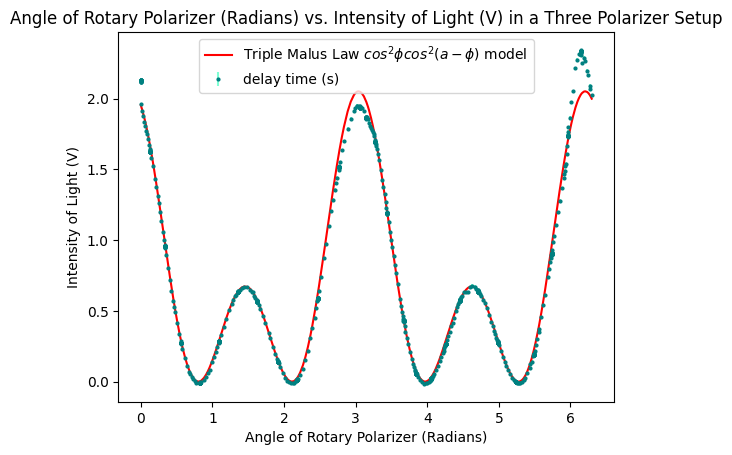

In [872]:
plt.errorbar(x = ex2_position_combined, y = ex2_intensity_combined, yerr=0.01, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="delay time (s)")

# plt.plot(LCnum, LC_to_prop_time(LCnum, popt[0]), label = "LC to velocity squared model", color='red')
# plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')
plt.plot(ex2_position_combined, coscos(ex2_position_combined, popt2[0], popt2[1], popt2[2], popt2[3]), label = "Triple Malus Law $cos^2\\phi cos^2(a-\\phi)$ model", color='red')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Rotary Polarizer (Radians)")
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Rotary Polarizer (Radians) vs. Intensity of Light (V) in a Three Polarizer Setup")

plt.show()

# Graphs for Curve Fit

# Graphs for Residuals

notes

ex2 questions, get answers by redoing setup

ask if this means angle wrt the readjusted polarizers for max and min, vs angle recorded from the data.


ASK

- ex2 questions about maxima and minima
    - get these values based on 0 in the detector (program screen).
- How should I fit 2q, should I find a function and then fit it?
    - $\cos^2x\cdot \cos^2{x - c}$ 
- how do I get uncertainties of the equipment?
    - run the detector on a fixed value get the stdev of the data. Note this down as an assumption in the report and notebook.

In [873]:
exercise_3_data_no_polarizer = np.loadtxt("../data/session3/no_polarizer.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
no_polarizer_position = exercise_3_data_no_polarizer[0]
no_polarizer_intensity = exercise_3_data_no_polarizer[1]

exercise_3_data_horizontal = np.loadtxt("../data/session2/horizontal.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
horizontal_position = exercise_3_data_horizontal[0]
horizontal_intensity = exercise_3_data_horizontal[1]

exercise_3_data_vertical = np.loadtxt("../data/session3/vertical.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
vertical_position = exercise_3_data_vertical[0]
vertical_intensity = exercise_3_data_vertical[1]

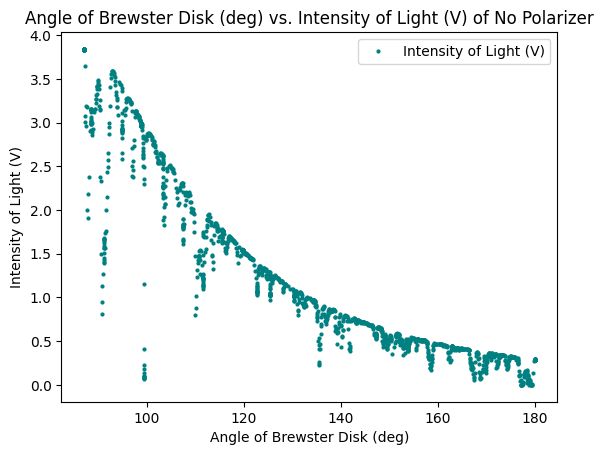

In [874]:
plt.errorbar(x = no_polarizer_position, y = no_polarizer_intensity, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# plt.plot(ex1_position, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), label = "LC to velocity squared model", color='red')
# plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Brewster Disk (deg)") # starts at 96 degrees and goes down
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Brewster Disk (deg) vs. Intensity of Light (V) of No Polarizer")

plt.show()

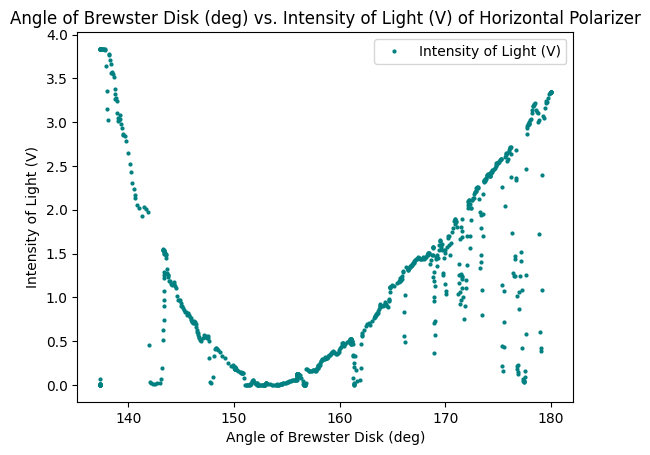

In [875]:
plt.errorbar(x = horizontal_position, y = horizontal_intensity, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# plt.plot(ex1_position, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), label = "LC to velocity squared model", color='red')
# plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Brewster Disk (deg)") # starts at 96 degrees and goes down
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Brewster Disk (deg) vs. Intensity of Light (V) of Horizontal Polarizer")

plt.show()

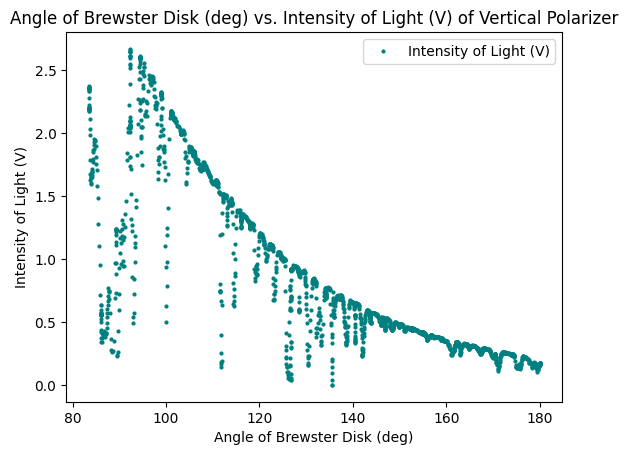

In [876]:
plt.errorbar(x = vertical_position, y = vertical_intensity, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# plt.plot(ex1_position, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), label = "LC to velocity squared model", color='red')
# plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Brewster Disk (deg)") # starts at 96 degrees and goes down
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Brewster Disk (deg) vs. Intensity of Light (V) of Vertical Polarizer")

plt.show()

Notes:

Get uncertainty

